# Capital Asset Pricing Model:
 - widely used model for determining the expected return of an asset based on its risk.

## CAPM is a model that describes the relationship between the excpected return and the risk of securities
## CAPM indicates that the expected return on a security is eqaul to the risk-free return plus a risk premiuim
# ri  = rf + βi (rm-rf)

# ri = Expected return on security
# rf = Risk free rate of return 
# βi = Beta between the stock and the market 
#      Stock's sensitivity to the market


# m = Expected return of the market

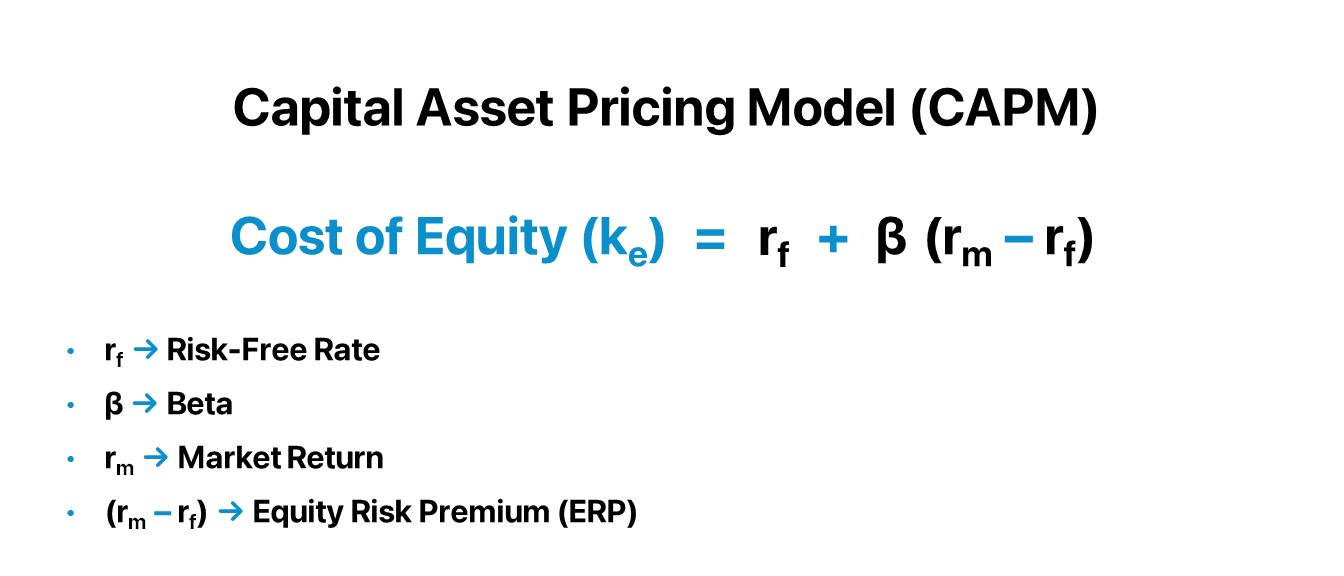

https://www.wallstreetprep.com/knowledge/capm-capital-asset-pricing-model/

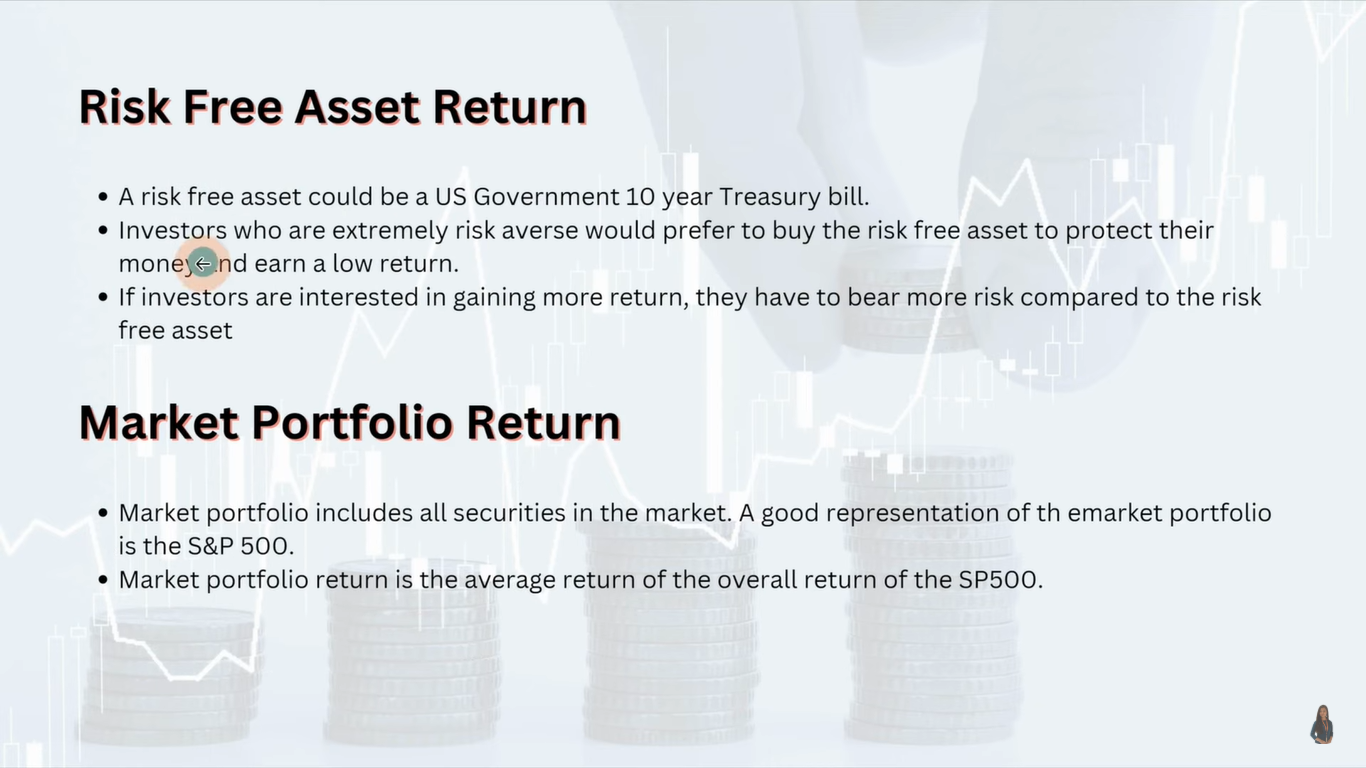

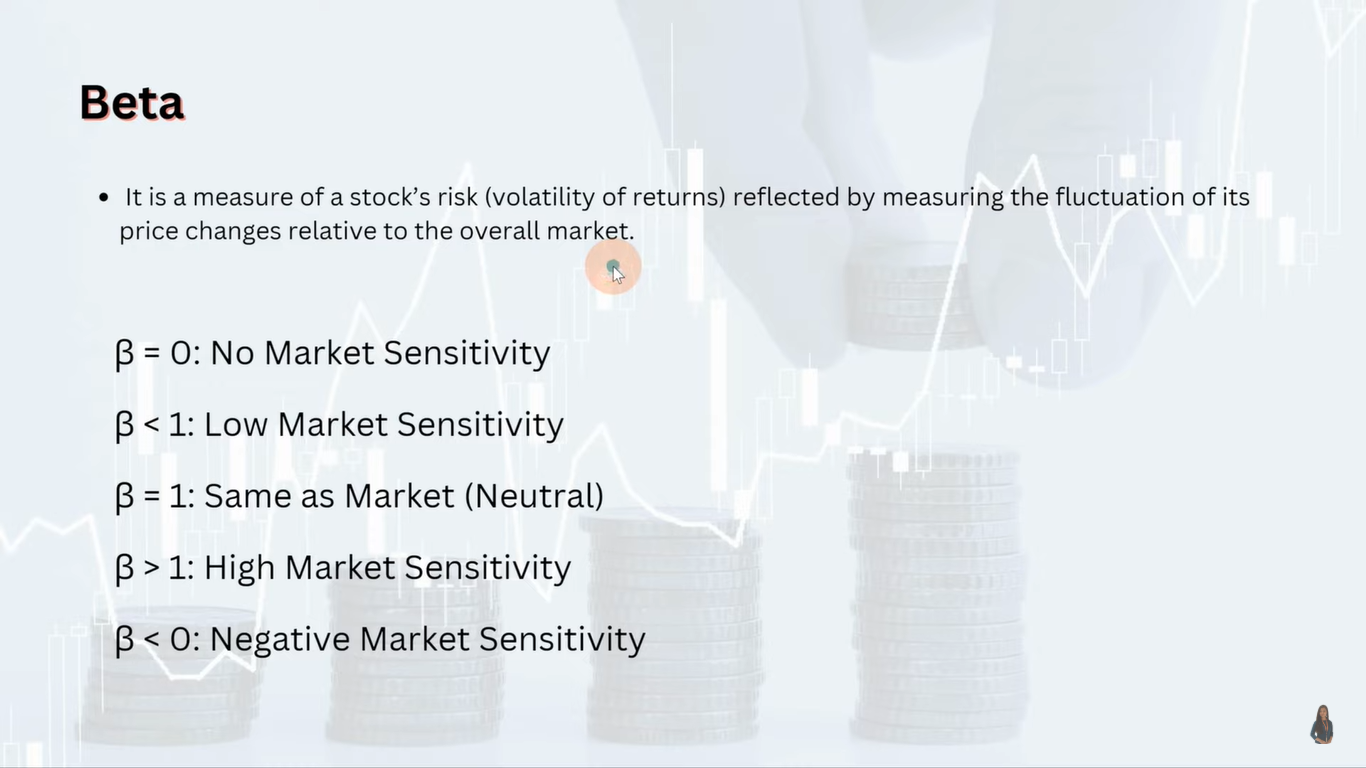

In [1]:
import yfinance as yf
import datetime
import pandas_datareader.data  as web 
import pandas as pd

import plotly.express as px
import numpy as np

C:\Users\SMIT\AppData\Roaming\Python\Python39\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\SMIT\AppData\Roaming\Python\Python39\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
C:\Users\Administrator\anaconda3\lib\site-packages\scipy\__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [42]:
year =1

In [43]:
end = datetime.datetime.today()
end

datetime.datetime(2026, 7, 18, 17, 30, 52, 109198)

In [44]:
start = datetime.date(2025,7,12)
start = datetime.date(datetime.date.today().year - year, 
                      datetime.date.today().month, 
                      datetime.date.today().day)
start

datetime.date(2025, 7, 18)

In [45]:
sp500 = web.DataReader(['sp500'], 'fred', start, end)
sp500.tail()

,sp500
DATE,
2026-07-13,7515.34
2026-07-14,7543.59
2026-07-15,7572.40
2026-07-16,7533.77
2026-07-17,7457.69


In [46]:
stocks_list = ["TSLA", "AAPL", "AMZN", "GOOGL"]

In [47]:
stocks_df = pd.DataFrame()
for stock in stocks_list:
    data = yf.download(stock, period=f'{year}y')
    stocks_df[stock] = data['Close']
stocks_df.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,TSLA,AAPL,AMZN,GOOGL
Date,,,,
2025-07-18,329.649994,210.345505,226.130005,184.533554
2025-07-21,328.489990,211.640366,229.300003,189.559235
2025-07-22,332.109985,213.552795,227.470001,190.795700
2025-07-23,332.559998,213.303772,228.289993,189.688858
2025-07-24,305.299988,212.915314,232.229996,191.623352


In [48]:
stocks_df.reset_index(inplace=True)
stocks_df.head()

,Date,TSLA,AAPL,AMZN,GOOGL
0,2025-07-18,329.649994,210.345505,226.130005,184.533554
1,2025-07-21,328.489990,211.640366,229.300003,189.559235
2,2025-07-22,332.109985,213.552795,227.470001,190.795700
3,2025-07-23,332.559998,213.303772,228.289993,189.688858
4,2025-07-24,305.299988,212.915314,232.229996,191.623352


In [49]:
sp500.reset_index(inplace=True)
sp500

,DATE,sp500
0,2025-07-18,6296.79
1,2025-07-21,6305.60
2,2025-07-22,6309.62
3,2025-07-23,6358.91
4,2025-07-24,6363.35
...,...,...
256,2026-07-13,7515.34
257,2026-07-14,7543.59
258,2026-07-15,7572.40
259,2026-07-16,7533.77


In [50]:
# sp500.rename(columns={'DATE': 'Date'}, inplace=True)

In [51]:
data = pd.merge(stocks_df, sp500, left_on='Date',right_on='DATE', how='inner').drop('DATE',axis=1)

In [52]:
data

,Date,TSLA,AAPL,AMZN,GOOGL,sp500
0,2025-07-18,329.649994,210.345505,226.130005,184.533554,6296.79
1,2025-07-21,328.489990,211.640366,229.300003,189.559235,6305.60
2,2025-07-22,332.109985,213.552795,227.470001,190.795700,6309.62
3,2025-07-23,332.559998,213.303772,228.289993,189.688858,6358.91
4,2025-07-24,305.299988,212.915314,232.229996,191.623352,6363.35
...,...,...,...,...,...,...
246,2026-07-13,394.760010,317.309998,247.309998,352.510010,7515.34
247,2026-07-14,396.179993,314.859985,247.490005,359.510010,7543.59
248,2026-07-15,394.459991,327.500000,254.960007,370.920013,7572.40
249,2026-07-16,391.059998,333.260010,249.889999,354.459991,7533.77


In [53]:
data.set_index('Date', inplace=True)

In [54]:
data

,TSLA,AAPL,AMZN,GOOGL,sp500
Date,,,,,
2025-07-18,329.649994,210.345505,226.130005,184.533554,6296.79
2025-07-21,328.489990,211.640366,229.300003,189.559235,6305.60
2025-07-22,332.109985,213.552795,227.470001,190.795700,6309.62
2025-07-23,332.559998,213.303772,228.289993,189.688858,6358.91
2025-07-24,305.299988,212.915314,232.229996,191.623352,6363.35
...,...,...,...,...,...
2026-07-13,394.760010,317.309998,247.309998,352.510010,7515.34
2026-07-14,396.179993,314.859985,247.490005,359.510010,7543.59
2026-07-15,394.459991,327.500000,254.960007,370.920013,7572.40


In [55]:
# functions to plot interactive plotly charts
def interactive_plot(df):
    fig = px.line()
    for i in df.columns:
        fig.add_scatter(x=df.index, y=df[i], name=i)
    fig.update_layout(
                    width=700,
                    margin=dict(l=20, r=20, t=50, b=20),
                    legend=dict(
                                orientation="h",
                                yanchor="bottom",
                                y=1.02,
                                xanchor="right",
                                x=1)
                    )

    return fig

In [56]:
interactive_plot(data)

In [57]:
def normalize(df2):
    df = df2.copy()
    return  df/df.max()

In [58]:
interactive_plot(normalize(data))

In [59]:
def daily_return(df):
    df_daily_return = df.copy()
    for i in df_daily_return.columns:
        df_daily_return[i] = df_daily_return[i].pct_change()
        
    df_daily_return.dropna(inplace=True)
    return df_daily_return

In [60]:
daily_returns  = daily_return(data)

In [61]:
interactive_plot(daily_returns)

In [62]:
def calculate_beta(stocks_daily_return_df,stocks):
    rm  =stocks_daily_return_df['sp500'].mean()*252
    b,a = np.polyfit(stocks_daily_return_df['sp500'], stocks_daily_return_df[stocks],1)
    return b,a                                                                          

In [65]:
beta = {}
alpha = {}
   
for i in daily_returns.columns:
    if i != 'Date' and i != 'sp500':
        b,a = calculate_beta(daily_returns,i)
        beta[i] = b
        alpha[i] = a    
print(beta)
print(alpha)

{'TSLA': 2.1231278015809756, 'AAPL': 0.8689446490361121, 'AMZN': 1.4371154304849427, 'GOOGL': 1.358119844933049}
{'TSLA': -0.0005321750999312338, 'AAPL': 0.0013505241264219975, 'AMZN': -0.000468822470738755, 'GOOGL': 0.0017462481004077786}


In [66]:
beta_df = pd.DataFrame(columns=['Stocks', 'Beta_values'])
beta_df['Stocks'] = beta.keys()
beta_df['Beta_values'] =[ str(round(i,2)) for i in beta.values()]

alpha_df = pd.DataFrame(columns=['Stocks', 'Alpha_values'])
alpha_df['Stocks'] = alpha.keys()
alpha_df['Alpha_values'] = [ str(round(i,2)) for i in alpha.values()]


In [67]:
beta_df

,Stocks,Beta_values
0,TSLA,2.12
1,AAPL,0.87
2,AMZN,1.44
3,GOOGL,1.36


In [68]:
alpha_df

,Stocks,Alpha_values
0,TSLA,-0.0
1,AAPL,0.0
2,AMZN,-0.0
3,GOOGL,0.0


In [69]:
# risk free rate = 0
rf = 0
rm  = daily_returns['sp500'].mean()*252
return_df = pd.DataFrame(columns=['Stocks', 'Return_values'])
return_values = []
for stock,value in beta.items():
    return_values.append(str(round(rf+ (value * (rm - rf)),2)))
return_df['Stocks'] = stocks_list
return_df['Return_values'] = return_values

In [70]:
return_df

,Stocks,Return_values
0,TSLA,0.38
1,AAPL,0.16
2,AMZN,0.26
3,GOOGL,0.24


In [71]:
data.head()

,TSLA,AAPL,AMZN,GOOGL,sp500
Date,,,,,
2025-07-18,329.649994,210.345505,226.130005,184.533554,6296.79
2025-07-21,328.489990,211.640366,229.300003,189.559235,6305.60
2025-07-22,332.109985,213.552795,227.470001,190.795700,6309.62
2025-07-23,332.559998,213.303772,228.289993,189.688858,6358.91
2025-07-24,305.299988,212.915314,232.229996,191.623352,6363.35


In [72]:
data.tail()

,TSLA,AAPL,AMZN,GOOGL,sp500
Date,,,,,
2026-07-13,394.760010,317.309998,247.309998,352.510010,7515.34
2026-07-14,396.179993,314.859985,247.490005,359.510010,7543.59
2026-07-15,394.459991,327.500000,254.960007,370.920013,7572.40
2026-07-16,391.059998,333.260010,249.889999,354.459991,7533.77
2026-07-17,380.839996,333.739990,247.229996,346.769989,7457.69


In [73]:
# st.plotly_chart(capm_functions.interactive_plot(df),use_container_width=True)

In [74]:
interactive_plot(data)

In [75]:
normalized_df = normalize(data)
interactive_plot(normalized_df)

In [76]:
daily_returns  = daily_return(normalized_df)
interactive_plot(daily_returns)

In [77]:
data

,TSLA,AAPL,AMZN,GOOGL,sp500
Date,,,,,
2025-07-18,329.649994,210.345505,226.130005,184.533554,6296.79
2025-07-21,328.489990,211.640366,229.300003,189.559235,6305.60
2025-07-22,332.109985,213.552795,227.470001,190.795700,6309.62
2025-07-23,332.559998,213.303772,228.289993,189.688858,6358.91
2025-07-24,305.299988,212.915314,232.229996,191.623352,6363.35
...,...,...,...,...,...
2026-07-13,394.760010,317.309998,247.309998,352.510010,7515.34
2026-07-14,396.179993,314.859985,247.490005,359.510010,7543.59
2026-07-15,394.459991,327.500000,254.960007,370.920013,7572.40
